<a href="https://colab.research.google.com/github/REDummy/hactiv8_assign/blob/main/assignment20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler


In [ ]:
df = pd.read_csv("Data/CC GENERAL.csv")

# Drop ID
df = df.drop("CUST_ID", axis=1)

print("Before : ")
print(df.isnull().sum())

# Handle missing values
df.fillna({"MINIMUM_PAYMENTS" : df["MINIMUM_PAYMENTS"].median()}, inplace=True)

print("\nAfter Minimum payment imputation : ")
print(df.isnull().sum())

df.fillna({"CREDIT_LIMIT" : df["CREDIT_LIMIT"].median()}, inplace=True)

df.isnull().sum()

Before : 
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

After Minimum payment imputation : 
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY             

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

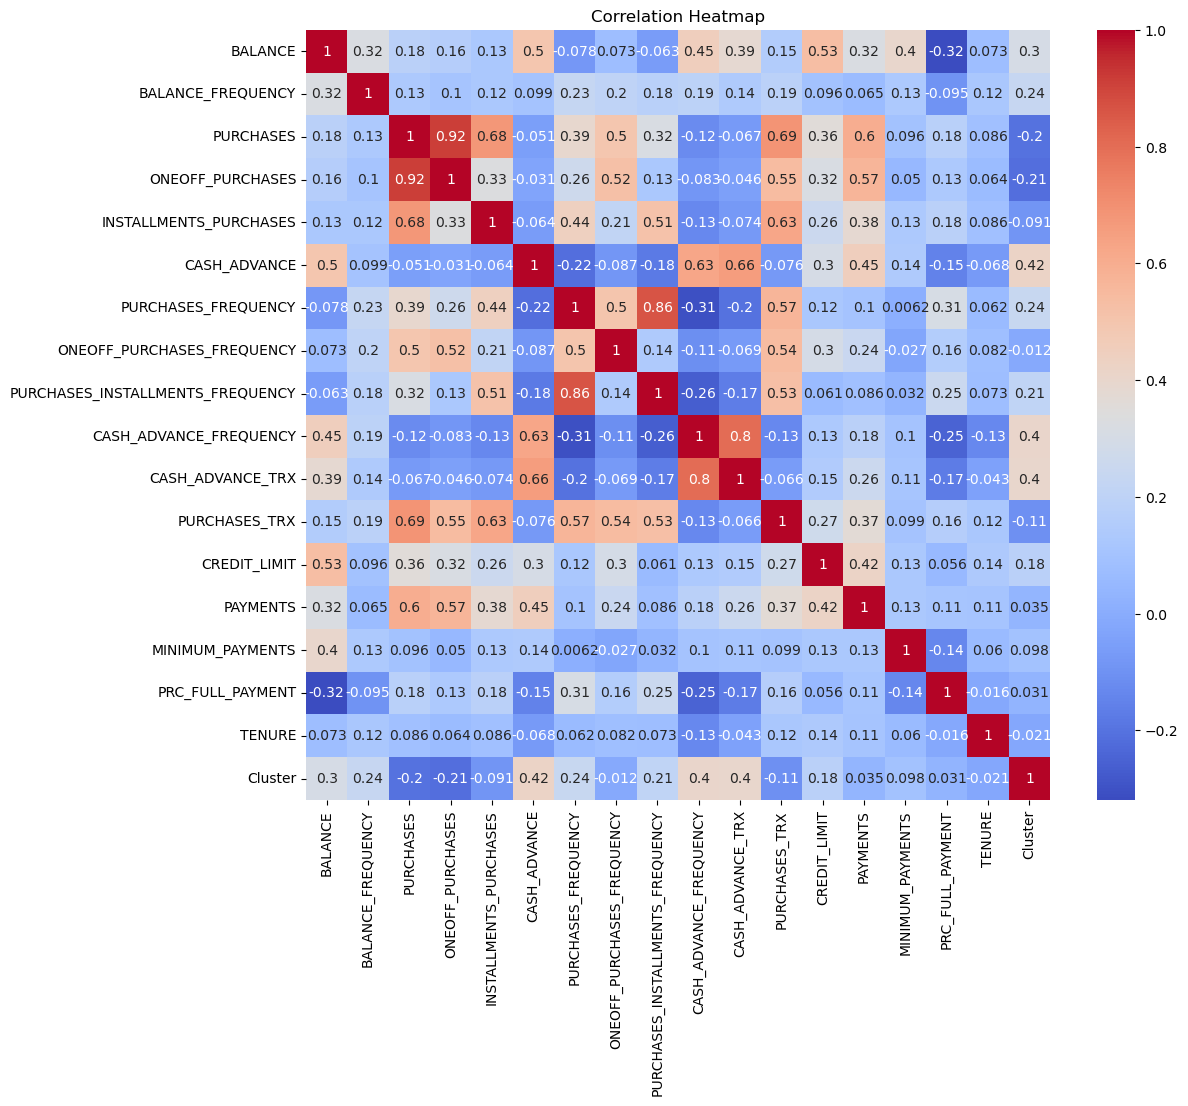

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

Top 3 correlated feature pairs:
1. More cash is possibly because of more credit limit
2. People who purchase more usually pay more frequently in installments

Interpretation:
These features show strong linear relationships and may represent
similar customer spending/payment behaviors.

In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

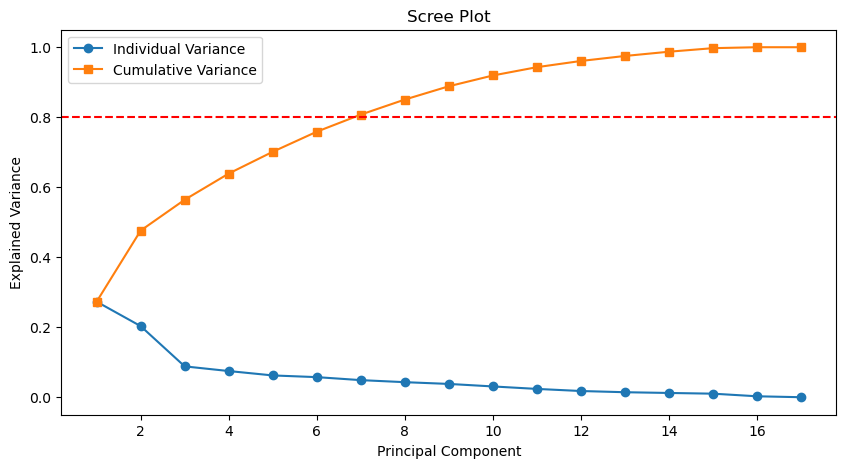

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', label="Individual Variance")
plt.plot(range(1, len(cum_var)+1), cum_var, marker='s', label="Cumulative Variance")

plt.axhline(y=0.8, color='r', linestyle='--')

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.legend()
plt.show()

In [ ]:
n_components = np.argmax(cum_var >= 0.8) + 1
print("Jumlah komponen untuk ≥80% variance:", n_components)

Jumlah komponen untuk ≥80% variance: 7


In [ ]:
pca_final = PCA(n_components=n_components)
X_pca = pca_final.fit_transform(X_scaled)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
inertia = []
silhouette = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_pca, labels))


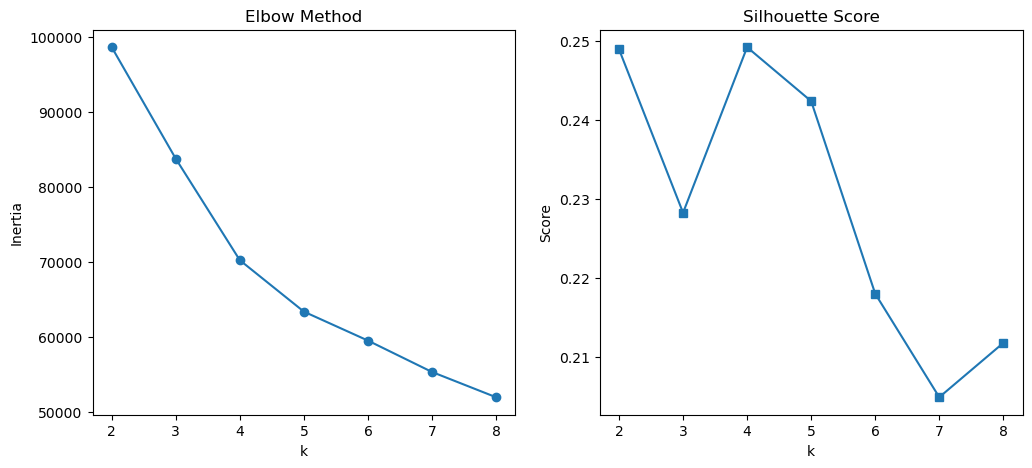

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Inertia
ax[0].plot(K_range, inertia, marker='o')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

# Silhouette
ax[1].plot(K_range, silhouette, marker='s')
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Score")

plt.show()


k = 4 because the elbow curve starts to flatten
around this point and the silhouette score remains relatively high.
This indicates a good balance between cluster compactness and separation.


In [ ]:

k_optimal = 4


kmeans = KMeans(n_clusters=k_optimal, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_pca)


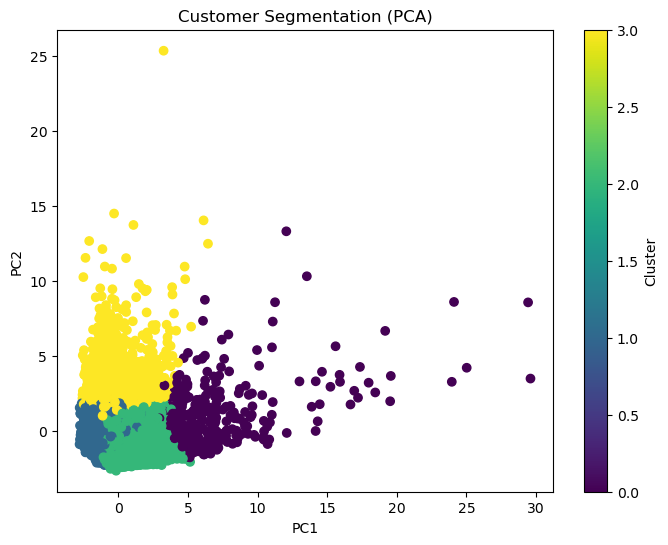

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation (PCA)")
plt.colorbar(label="Cluster")

plt.show()

In [ ]:
cluster_profile = df.groupby("Cluster").mean()
cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,3703.957264,0.987588,8046.738107,5398.326347,2650.011760,731.941367,0.944449,0.742036,0.778178,0.076420,2.312000,90.117333,9859.600000,7706.221346,2100.079873,0.285413,11.962667
1,999.822895,0.788553,277.399948,213.779052,63.885127,574.260157,0.178620,0.088059,0.087093,0.112179,2.065704,3.032603,3258.238759,966.423343,559.758773,0.077669,11.443753
2,906.103725,0.938289,1273.998227,611.217915,663.057324,208.864358,0.890904,0.303619,0.719179,0.042622,0.787879,22.942994,4279.304006,1354.295231,635.000055,0.273985,11.602160
3,4555.337929,0.968551,490.463554,311.918750,178.627868,4479.490382,0.283816,0.137214,0.182138,0.480464,14.120915,7.520425,7493.426916,3451.674409,1967.989931,0.035500,11.391340


**CLUSTER 0**
Customers in this cluster tend to have low balances and low purchase activity.
They use their credit cards moderately and maintain lower cash advance usage.

Recommended Promotion:
Offer cashback promotions and spending rewards to encourage more transactions.



**CLUSTER 1**
Customers in this cluster show high purchase frequency and large transaction values.
They appear to be active credit card users with strong repayment behavior.

Recommended Promotion:
Provide premium rewards, travel benefits, and exclusive loyalty programs.



**CLUSTER 2**
Customers in this cluster rely heavily on cash advances and maintain higher balances.
This may indicate greater dependency on credit facilities.

Recommended Promotion:
Offer installment plans, lower interest programs, or financial management assistance.



**CLUSTER 3**
Customers in this cluster have high credit limits and frequent card usage across categories.
They represent valuable long-term customers.

Recommended Promotion:
Offer VIP services, higher-tier cards, and personalized banking offers.